# IDX Exchange – MLS Analytics Internship
**Intern:** Sumire Garcia  
**Program:** IDX Exchange Data Analyst Internship – MLS Analytics & Tableau Dashboard Program  
**Data:** CRMLS monthly Listing & Sold CSVs, February 2024 – April 2026  
**Tools:** Python / Pandas, Spyder → Jupyter

---
This notebook combines all weekly deliverables for both the **Sold** and **Listing** datasets in a single file. Each week is a clearly marked section. Run all cells top-to-bottom, or jump to any week — earlier weeks must have run first since each builds on the previous output.


## Configuration

In [3]:
import pandas as pd
import numpy as np
import os
import glob
import warnings
import matplotlib.pyplot as plt
import matplotlib
import requests, io
warnings.filterwarnings('ignore')

# ── UPDATE THIS to your local CSV folder ──────────────────────────────────
SOLD_PATH    = r"/Users/sumiregarcia/Desktop/INTERSHIP/IDX/CVS/SOLD"
LISTING_PATH = r"/Users/sumiregarcia/Desktop/INTERSHIP/IDX/CVS/LISTING"

OUTPUT_PATH = os.path.join(os.path.dirname(SOLD_PATH), "output")
os.makedirs(OUTPUT_PATH, exist_ok=True)

print("Configuration set.")
print(f"Output folder: {OUTPUT_PATH}")

Configuration set.
Output folder: /Users/sumiregarcia/Desktop/INTERSHIP/IDX/CVS/output


---
## Week 1 – Monthly Dataset Aggregation
Load all monthly CSVs, concatenate into two unified datasets, filter to `PropertyType == 'Residential'`, and save combined CSVs.

> **Note – `_filled` duplicates (Sold):** Some months have both a base file and a `_filled` variant (e.g. `CRMLSSold202401.csv` + `CRMLSSold202401_filled.csv`). The script detects these and keeps only one file per month — the `_filled` version when both exist, since it contains more complete data.


In [4]:
# ── Sold: deduplicate _filled files, prefer _filled over base ─────────────
all_sold_files = sorted(glob.glob(os.path.join(SOLD_PATH, "CRMLSSold*.csv")))

# Build a dict: month_key → file path, preferring _filled when both exist
sold_file_map = {}
for f in all_sold_files:
    base = os.path.basename(f)
    month_key = base.replace("_filled", "").replace(".csv", "")  # e.g. CRMLSSold202401
    if month_key not in sold_file_map or "_filled" in base:
        sold_file_map[month_key] = f

sold_files_deduped = sorted(sold_file_map.values())
print(f"Sold files found    : {len(all_sold_files)}  (including _filled variants)")
print(f"Sold files after dedup: {len(sold_files_deduped)}  (one per month)")

# ── Listing: load all files ───────────────────────────────────────────────
listing_files = sorted(glob.glob(os.path.join(LISTING_PATH, "CRMLSListing*.csv")))
print(f"\nListing files found : {len(listing_files)}")

# ── Concatenate ────────────────────────────────────────────────────────────
sold_raw = pd.concat(
    [pd.read_csv(f, low_memory=False) for f in sold_files_deduped],
    ignore_index=True
)

listing_frames = []
for f in listing_files:
    df = pd.read_csv(f, low_memory=False)
    dupe_cols = [c for c in df.columns if c.endswith(".1")]
    df = df.drop(columns=dupe_cols)
    listing_frames.append(df)
listing_raw = pd.concat(listing_frames, ignore_index=True)

print(f"\n{'':30} {'Sold':>12} {'Listing':>12}")
print(f"{'Rows before filter':30} {len(sold_raw):>12,} {len(listing_raw):>12,}")

# ── Residential filter ─────────────────────────────────────────────────────
sold    = sold_raw[sold_raw["PropertyType"] == "Residential"].copy()
listing = listing_raw[listing_raw["PropertyType"] == "Residential"].copy()

print(f"{'Rows after Residential filter':30} {len(sold):>12,} {len(listing):>12,}")
print(f"{'Rows removed':30} {len(sold_raw)-len(sold):>12,} {len(listing_raw)-len(listing):>12,}")

sold.to_csv(os.path.join(OUTPUT_PATH, "sold_residential_combined.csv"), index=False)
listing.to_csv(os.path.join(OUTPUT_PATH, "listing_residential_combined.csv"), index=False)
print("\n Week 1 complete — sold_residential_combined.csv, listing_residential_combined.csv")

Sold files found    : 31  (including _filled variants)
Sold files after dedup: 28  (one per month)

Listing files found : 27

                                       Sold      Listing
Rows before filter                  615,707      866,140
Rows after Residential filter       414,054      550,542
Rows removed                        201,653      315,598

Week 1 complete — sold_residential_combined.csv, listing_residential_combined.csv


---
## Week 2 – Dataset Structuring and Validation
Inspect structure, run missing value analysis, and flag date consistency issues.  
Columns with >90% missing values are dropped. Remaining columns are evaluated against the final Tableau dashboard requirements — only fields that contribute to market analysis, competitive analysis, or geographic filtering are kept.


In [5]:
# ── Columns to keep (dashboard-relevant fields only) ──────────────────────
KEEP_COLS = [
    # Price & market metrics
    "ClosePrice", "ListPrice", "OriginalListPrice", "LivingArea",
    "DaysOnMarket", "BedroomsTotal", "BathroomsTotalInteger",
    "LotSizeAcres", "YearBuilt",
    # Dates
    "CloseDate", "ListingContractDate", "PurchaseContractDate",
    "ContractStatusChangeDate",
    # Geography & filters
    "Latitude", "Longitude", "CountyOrParish", "City", "PostalCode",
    "MLSAreaMajor", "StateOrProvince", "UnparsedAddress",
    # Property info
    "PropertyType", "PropertySubType", "MlsStatus", "NewConstructionYN",
    # Agent & office (competitive analysis)
    "ListAgentFullName", "ListAgentFirstName", "ListAgentLastName",
    "ListAgentEmail", "ListOfficeName",
    "BuyerAgentFirstName", "BuyerAgentLastName", "BuyerOfficeName",
    # Keys
    "ListingKey", "ListingId",
    # Supplemental property details
    "AssociationFee", "AssociationFeeFrequency",
    "GarageSpaces", "ParkingTotal", "Stories", "Levels", "FireplaceYN",
]

def trim_columns(df, label):
    # Drop >90% null columns first
    threshold = 0.90 * len(df)
    high_null = [c for c in df.columns if df[c].isnull().sum() > threshold]
    df = df.drop(columns=high_null)
    # Then keep only dashboard-relevant columns that exist
    keep = [c for c in KEEP_COLS if c in df.columns]
    dropped_other = [c for c in df.columns if c not in keep]
    df = df[keep]
    print(f"{label}:")
    print(f"  Dropped (>90% null)          : {len(high_null)} columns → {high_null}")
    print(f"  Dropped (not dashboard-relevant): {len(dropped_other)} columns")
    print(f"  Columns retained             : {df.shape[1]}")
    return df

print("── Column Trimming ──────────────────────────────────────────────────")
sold    = trim_columns(sold, "Sold")
listing = trim_columns(listing, "Listing")

── Column Trimming ──────────────────────────────────────────────────
Sold:
  Dropped (>90% null)          : 15 columns → ['WaterfrontYN', 'BasementYN', 'FireplacesTotal', 'AboveGradeFinishedArea', 'TaxAnnualAmount', 'BuilderName', 'TaxYear', 'BuildingAreaTotal', 'ElementarySchoolDistrict', 'CoBuyerAgentFirstName', 'BelowGradeFinishedArea', 'BusinessType', 'CoveredSpaces', 'LotSizeDimensions', 'MiddleOrJuniorSchoolDistrict']
  Dropped (not dashboard-relevant): 25 columns
  Columns retained             : 42
Listing:
  Dropped (>90% null)          : 13 columns → ['FireplacesTotal', 'AboveGradeFinishedArea', 'TaxAnnualAmount', 'BuilderName', 'TaxYear', 'BuildingAreaTotal', 'ElementarySchoolDistrict', 'CoBuyerAgentFirstName', 'BelowGradeFinishedArea', 'BusinessType', 'CoveredSpaces', 'LotSizeDimensions', 'MiddleOrJuniorSchoolDistrict']
  Dropped (not dashboard-relevant): 18 columns
  Columns retained             : 42


In [6]:
# ── Missing value summary (after trimming) ────────────────────────────────
def missing_summary(df, label):
    total = len(df)
    miss  = df.isnull().sum()
    pct   = (miss / total * 100).round(2)
    report = pd.DataFrame({"missing_count": miss, "missing_pct": pct})
    report = report[report["missing_count"] > 0].sort_values("missing_pct", ascending=False)
    report.to_csv(os.path.join(OUTPUT_PATH, f"{label}_missing_report.csv"))
    print(f"{label} — {len(report)} columns have nulls (report saved)")
    print(report.to_string())
    return report

print("── Missing Value Analysis ───────────────────────────────────────────")
sold_missing    = missing_summary(sold, "sold")
print()
listing_missing = missing_summary(listing, "listing")

── Missing Value Analysis ───────────────────────────────────────────
sold — 32 columns have nulls (report saved)
                          missing_count  missing_pct
AssociationFeeFrequency          241538        58.33
AssociationFee                    94697        22.87
Stories                           63795        15.41
MLSAreaMajor                      55359        13.37
Levels                            39919         9.64
LotSizeAcres                      32535         7.86
NewConstructionYN                 30730         7.42
GarageSpaces                      17760         4.29
BuyerOfficeName                    6742         1.63
Latitude                           4104         0.99
Longitude                          4104         0.99
ListAgentFirstName                 3109         0.75
BuyerAgentFirstName                2010         0.49
ListAgentEmail                     1065         0.26
PropertySubType                     804         0.19
OriginalListPrice                   75

In [7]:
# ── EDA answers ───────────────────────────────────────────────────────────
print("── EDA Summary ─────────────────────────────────────────────────────")
print(f"\nSOLD  shape: {sold.shape[0]:,} rows x {sold.shape[1]} cols")
print(f"LISTING shape: {listing.shape[0]:,} rows x {listing.shape[1]} cols")

# Close price
cp = sold["ClosePrice"].dropna()
print(f"\nSold — Median ClosePrice: ${cp.median():,.0f}  |  Mean: ${cp.mean():,.0f}")

# DOM
dom = sold["DaysOnMarket"].dropna()
print(f"Sold — DOM Median: {dom.median():.0f} days  |  Mean: {dom.mean():.1f}  |  Max: {dom.max():.0f}")
for label, mask in [("1-7 days",  (dom>=1)&(dom<=7)), ("8-30 days", (dom>=8)&(dom<=30)),
                    ("31-60 days",(dom>=31)&(dom<=60)), ("60+ days",  dom>60)]:
    n = mask.sum(); print(f"  {label}: {n:,} ({n/len(dom)*100:.1f}%)")

# Above/below list
both  = sold[["ClosePrice","ListPrice"]].dropna(); n = len(both)
above = (both["ClosePrice"] > both["ListPrice"]).sum()
below = (both["ClosePrice"] < both["ListPrice"]).sum()
print(f"\nSold above list: {above:,} ({above/n*100:.1f}%)  |  Below: {below:,} ({below/n*100:.1f}%)")

# County medians
print("\nTop 10 counties by median ClosePrice:")
print(sold.groupby("CountyOrParish")["ClosePrice"].median()
      .sort_values(ascending=False).head(10).to_string())

# Listing status
print("\nListing — MlsStatus breakdown:")
print(listing["MlsStatus"].value_counts().to_string())

lp = listing["ListPrice"].dropna()
print(f"\nListing — Median ListPrice: ${lp.median():,.0f}  |  Mean: ${lp.mean():,.0f}")

── EDA Summary ─────────────────────────────────────────────────────

SOLD  shape: 414,054 rows x 42 cols
LISTING shape: 550,542 rows x 42 cols

Sold — Median ClosePrice: $823,000  |  Mean: $1,193,864
Sold — DOM Median: 18 days  |  Mean: 37.4  |  Max: 12430
  1-7 days: 84,630 (20.4%)
  8-30 days: 159,470 (38.5%)
  31-60 days: 73,026 (17.6%)
  60+ days: 80,344 (19.4%)

Sold above list: 166,026 (40.1%)  |  Below: 176,179 (42.5%)

Top 10 counties by median ClosePrice:
CountyOrParish
Del Norte        2485000.0
San Mateo        1700000.0
Santa Clara      1600000.0
Santa Cruz       1200000.0
San Francisco    1198950.0
Orange           1175000.0
Marin            1165000.0
Alameda          1134000.0
Other County     1100000.0
Alpine           1100000.0

Listing — MlsStatus breakdown:
MlsStatus
Active                 286430
Closed                 127140
Pending                 90913
ActiveUnderContract     44248
ComingSoon               1811

Listing — Median ListPrice: $849,000  |  Mean: $1,31

In [8]:
# ── Date consistency flags ────────────────────────────────────────────────
def add_date_flags(df):
    for col in ["CloseDate","PurchaseContractDate","ListingContractDate","ContractStatusChangeDate"]:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")
    if "ListingContractDate" in df.columns and "CloseDate" in df.columns:
        df["listing_after_close_flag"]  = df["ListingContractDate"] > df["CloseDate"]
    if "PurchaseContractDate" in df.columns and "CloseDate" in df.columns:
        df["purchase_after_close_flag"] = df["PurchaseContractDate"] > df["CloseDate"]
    if "ListingContractDate" in df.columns and "PurchaseContractDate" in df.columns:
        df["negative_timeline_flag"]    = df["ListingContractDate"] > df["PurchaseContractDate"]
    return df

sold    = add_date_flags(sold)
listing = add_date_flags(listing)

for label, df in [("Sold", sold), ("Listing", listing)]:
    for flag in ["listing_after_close_flag","purchase_after_close_flag","negative_timeline_flag"]:
        if flag in df.columns:
            n = df[flag].sum()
            print(f"{label} — {flag}: {n:,} ({n/len(df)*100:.2f}%)")

print("\n Week 2 complete")

Sold — listing_after_close_flag: 61 (0.01%)
Sold — purchase_after_close_flag: 239 (0.06%)
Sold — negative_timeline_flag: 268 (0.06%)
Listing — listing_after_close_flag: 71 (0.01%)
Listing — purchase_after_close_flag: 255 (0.05%)
Listing — negative_timeline_flag: 268 (0.05%)

 Week 2 complete


---
## Week 3 – Numeric Distributions + Mortgage Rate Enrichment
Generate percentile distribution tables and charts for key numeric fields. Fetch 30-year fixed mortgage rate from FRED, resample weekly → monthly, and merge onto both datasets by year-month key.


In [9]:
# ── Numeric distribution summary ──────────────────────────────────────────
NUMERIC_SOLD    = ["ClosePrice","ListPrice","OriginalListPrice","LivingArea",
                   "LotSizeAcres","BedroomsTotal","BathroomsTotalInteger","DaysOnMarket","YearBuilt"]
NUMERIC_LISTING = ["ListPrice","OriginalListPrice","LivingArea","LotSizeAcres",
                   "BedroomsTotal","BathroomsTotalInteger","DaysOnMarket","YearBuilt"]

PCTS = [0.01,0.05,0.10,0.25,0.50,0.75,0.90,0.95,0.99]

sold_dist    = sold[[c for c in NUMERIC_SOLD    if c in sold.columns]].describe(percentiles=PCTS)
listing_dist = listing[[c for c in NUMERIC_LISTING if c in listing.columns]].describe(percentiles=PCTS)

print("Sold numeric distributions:")
display(sold_dist.round(2))

sold_dist.to_csv(os.path.join(OUTPUT_PATH, "sold_numeric_distribution.csv"))
listing_dist.to_csv(os.path.join(OUTPUT_PATH, "listing_numeric_distribution.csv"))

Sold numeric distributions:


,ClosePrice,ListPrice,OriginalListPrice,LivingArea,LotSizeAcres,BedroomsTotal,BathroomsTotalInteger,DaysOnMarket,YearBuilt
count,4.140520e+05,4.140540e+05,4.132980e+05,413820.00,381519.00,414043.00,413985.00,414054.00,413682.00
mean,1.193864e+06,1.140462e+06,1.225401e+06,1903.79,66.30,3.20,2.53,37.36,1978.58
std,6.290122e+06,1.359497e+06,6.709938e+06,26476.20,15998.18,1.07,1.13,53.59,26.28
min,0.000000e+00,5.250000e+02,0.000000e+00,0.00,0.00,0.00,0.00,-288.00,1776.00
1%,2.023020e+05,2.149000e+05,2.100000e+05,604.00,0.00,1.00,1.00,0.00,1912.00
5%,3.400000e+05,3.470000e+05,3.499000e+05,840.00,0.03,2.00,1.00,1.00,1930.00
10%,4.150000e+05,4.190000e+05,4.250000e+05,983.00,0.06,2.00,1.00,4.00,1947.00
25%,5.750000e+05,5.761670e+05,5.850000e+05,1248.00,0.12,3.00,2.00,8.00,1960.00
50%,8.230000e+05,8.150000e+05,8.250000e+05,1642.00,0.17,3.00,2.00,18.00,1979.00
75%,1.300000e+06,1.295000e+06,1.299000e+06,2219.00,0.27,4.00,3.00,48.00,1999.00


In [10]:
print("Listing numeric distributions:")
display(listing_dist.round(2))

Listing numeric distributions:


,ListPrice,OriginalListPrice,LivingArea,LotSizeAcres,BedroomsTotal,BathroomsTotalInteger,DaysOnMarket,YearBuilt
count,5.505420e+05,5.497530e+05,549982.00,505301.00,550390.00,550491.00,550542.00,549595.00
mean,1.319507e+06,1.401826e+06,1982.37,64.08,3.23,2.63,18.26,1979.66
std,2.407016e+06,7.289769e+06,23162.33,12018.23,1.19,3.23,25.91,27.03
min,1.000000e+02,0.000000e+00,0.00,0.00,0.00,0.00,-39.00,1776.00
1%,2.120000e+05,2.000000e+05,588.00,0.00,1.00,1.00,0.00,1911.00
5%,3.477023e+05,3.490000e+05,817.00,0.03,2.00,1.00,0.00,1929.00
10%,4.199990e+05,4.200000e+05,963.00,0.06,2.00,1.00,1.00,1947.00
25%,5.849000e+05,5.870000e+05,1248.00,0.12,2.00,2.00,5.00,1961.00
50%,8.490000e+05,8.490000e+05,1672.00,0.17,3.00,2.00,10.00,1980.00
75%,1.388880e+06,1.395000e+06,2302.00,0.32,4.00,3.00,21.00,2001.00


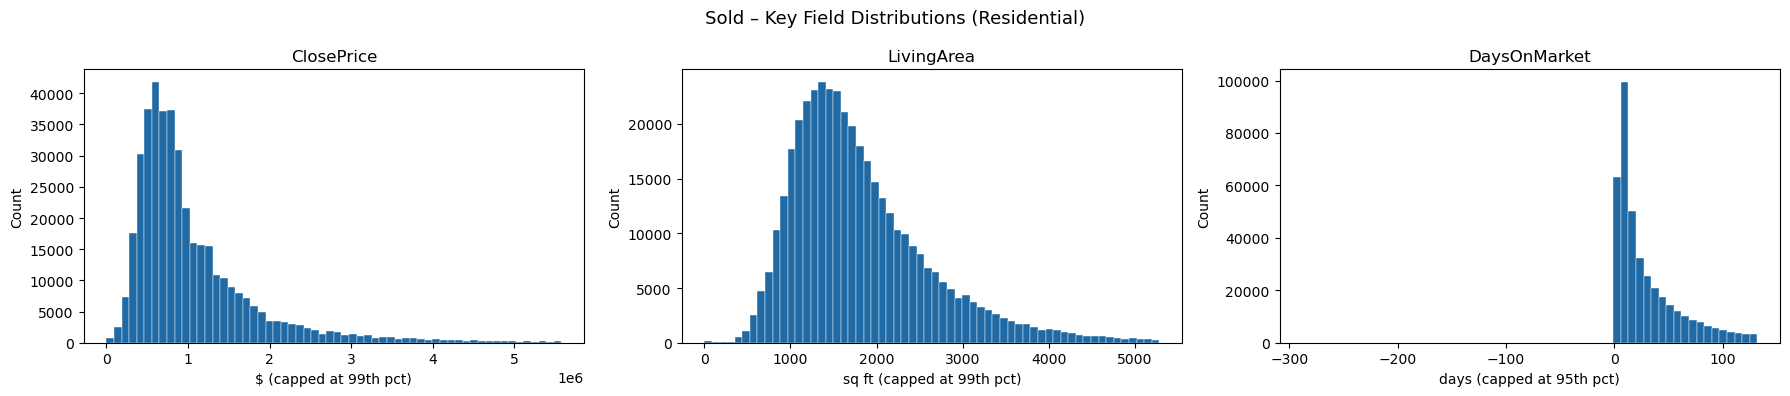

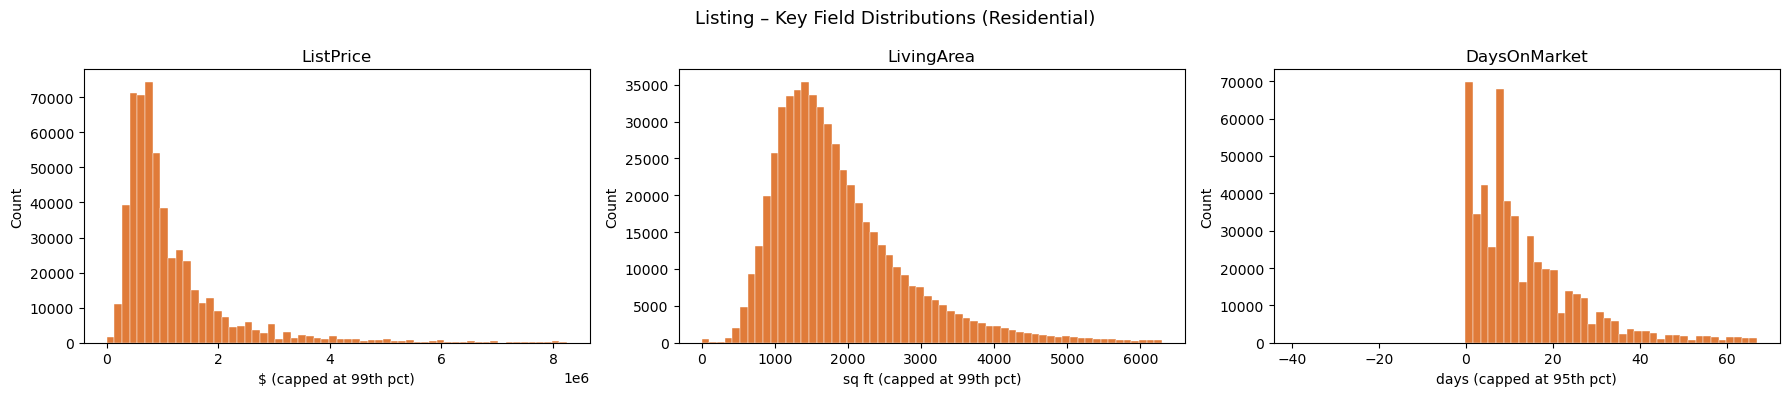

In [11]:
# ── Distribution charts ───────────────────────────────────────────────────
def dist_charts(df, fields, caps, units, color, title_prefix, fname):
    fields = [(f, c, u) for f, c, u in zip(fields, caps, units) if f in df.columns]
    fig, axes = plt.subplots(1, len(fields), figsize=(6*len(fields), 4))
    if len(fields) == 1: axes = [axes]
    fig.suptitle(f"{title_prefix} – Key Field Distributions (Residential)", fontsize=13)
    for ax, (field, cap_pct, unit) in zip(axes, fields):
        s = df[field].dropna()
        cap = s.quantile(cap_pct)
        s   = s[s <= cap]
        ax.hist(s, bins=60, color=color, edgecolor="white", linewidth=0.3)
        ax.set_title(field); ax.set_xlabel(f"{unit} (capped at {int(cap_pct*100)}th pct)")
        ax.set_ylabel("Count")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_PATH, fname), dpi=150)
    plt.show()

dist_charts(sold,    ["ClosePrice","LivingArea","DaysOnMarket"], [0.99,0.99,0.95],
            ["$","sq ft","days"], "#1f6aa5", "Sold",    "sold_histograms.png")
dist_charts(listing, ["ListPrice","LivingArea","DaysOnMarket"],  [0.99,0.99,0.95],
            ["$","sq ft","days"], "#e07b39", "Listing", "listing_histograms.png")

In [12]:
# ── FRED mortgage rate enrichment ─────────────────────────────────────────
fred_url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=MORTGAGE30US"
mortgage = pd.read_csv(fred_url, parse_dates=["observation_date"])
mortgage.columns = ["date", "rate_30yr_fixed"]
mortgage["year_month"] = mortgage["date"].dt.to_period("M")
mortgage_monthly = mortgage.groupby("year_month")["rate_30yr_fixed"].mean().reset_index()

print(f"Fetched {len(mortgage)} weekly → {len(mortgage_monthly)} monthly observations")
print("\nMost recent 6 months:")
display(mortgage_monthly.tail(6))

# Merge onto Sold (key: CloseDate) and Listing (key: ListingContractDate)
sold["year_month"]    = pd.to_datetime(sold["CloseDate"], errors="coerce").dt.to_period("M")
listing["year_month"] = pd.to_datetime(listing["ListingContractDate"], errors="coerce").dt.to_period("M")

sold    = sold.merge(mortgage_monthly,    on="year_month", how="left")
listing = listing.merge(mortgage_monthly, on="year_month", how="left")

print(f"\nNull rate_30yr_fixed — Sold: {sold['rate_30yr_fixed'].isnull().sum():,}  |  "
      f"Listing: {listing['rate_30yr_fixed'].isnull().sum():,}")

sold.to_csv(os.path.join(OUTPUT_PATH, "sold_enriched.csv"), index=False)
listing.to_csv(os.path.join(OUTPUT_PATH, "listing_enriched.csv"), index=False)
print("\n Week 3 complete — sold_enriched.csv, listing_enriched.csv")

Fetched 2887 weekly → 664 monthly observations

Most recent 6 months:


,year_month,rate_30yr_fixed
658,2026-02,6.0475
659,2026-03,6.1775
660,2026-04,6.3320
661,2026-05,6.4425
662,2026-06,6.4900
663,2026-07,6.5125



Null rate_30yr_fixed — Sold: 0  |  Listing: 0

 Week 3 complete — sold_enriched.csv, listing_enriched.csv


---
## Weeks 4–5 – Data Cleaning and Preparation
Enforce numeric types, flag invalid values, and run geographic coordinate checks.  
**Strategy:** flag, don't delete. Each issue gets a `flag_` boolean column. Only fundamentally unusable records are excluded from the clean file. Statistical outliers (e.g. $989M ClosePrice, DOM 12,430) are preserved here and handled by IQR in Week 7.


In [13]:
sold    = pd.read_csv(os.path.join(OUTPUT_PATH, "sold_enriched.csv"),    low_memory=False)
listing = pd.read_csv(os.path.join(OUTPUT_PATH, "listing_enriched.csv"), low_memory=False)

# Re-convert dates (lost after CSV round-trip)
DATE_COLS = ["CloseDate","ListingContractDate","PurchaseContractDate","ContractStatusChangeDate"]
for col in DATE_COLS:
    for df in [sold, listing]:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")

# Enforce numeric types
NUMERIC_COLS = ["ClosePrice","ListPrice","OriginalListPrice","LivingArea","LotSizeAcres",
                "BedroomsTotal","BathroomsTotalInteger","DaysOnMarket","YearBuilt",
                "Latitude","Longitude"]
for col in NUMERIC_COLS:
    for df in [sold, listing]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

print("Date conversion and numeric type enforcement done.")

Date conversion and numeric type enforcement done.


In [14]:
# ── Invalid value flags ───────────────────────────────────────────────────
def add_validity_flags(df, price_col):
    # Price
    df[f"flag_invalid_{price_col.lower()}"] = df[price_col].le(0) | df[price_col].isnull()
    # Living area
    df["flag_invalid_living_area"]  = df["LivingArea"].le(0)  | df["LivingArea"].isnull()
    # DOM
    if "DaysOnMarket" in df.columns:
        df["flag_negative_dom"]     = df["DaysOnMarket"] < 0
    # Bedrooms / Bathrooms
    if "BedroomsTotal" in df.columns:
        df["flag_invalid_bedrooms"] = df["BedroomsTotal"].le(0) | df["BedroomsTotal"].isnull()
    if "BathroomsTotalInteger" in df.columns:
        df["flag_invalid_bathrooms"]= df["BathroomsTotalInteger"].le(0) | df["BathroomsTotalInteger"].isnull()
    # Year built
    if "YearBuilt" in df.columns:
        df["flag_invalid_year_built"] = df["YearBuilt"].lt(1800) | df["YearBuilt"].gt(2026)
    # Coordinates — California bounds: lat 32.5–42.0, lon -124.5 to -114.1 (all negative)
    if "Latitude" in df.columns:
        df["flag_missing_lat"]       = df["Latitude"].isnull()
        df["flag_zero_lat"]          = df["Latitude"] == 0
        df["flag_out_of_range_lat"]  = df["Latitude"].notna() & ((df["Latitude"] < 32.5) | (df["Latitude"] > 42.0))
    if "Longitude" in df.columns:
        df["flag_missing_lon"]       = df["Longitude"].isnull()
        df["flag_zero_lon"]          = df["Longitude"] == 0
        df["flag_positive_lon"]      = df["Longitude"].notna() & (df["Longitude"] > 0)
        df["flag_out_of_range_lon"]  = df["Longitude"].notna() & ((df["Longitude"] < -124.5) | (df["Longitude"] > -114.1))
    return df

sold    = add_validity_flags(sold,    "ClosePrice")
listing = add_validity_flags(listing, "ListPrice")

# ── Print flag summary ────────────────────────────────────────────────────
def flag_summary(df, label):
    flags = [c for c in df.columns if c.startswith("flag_")]
    rows  = []
    for f in flags:
        n = df[f].sum(); rows.append({"flag": f, "count": n, "pct": round(n/len(df)*100, 2)})
    summary = pd.DataFrame(rows)
    print(f"\n{label} flag summary ({len(df):,} total rows):")
    display(summary)
    return summary

sold_flags    = flag_summary(sold,    "Sold")
listing_flags = flag_summary(listing, "Listing")


Sold flag summary (414,054 total rows):


,flag,count,pct
0,flag_invalid_closeprice,3,0.00
1,flag_invalid_living_area,384,0.09
2,flag_negative_dom,48,0.01
3,flag_invalid_bedrooms,1188,0.29
4,flag_invalid_bathrooms,382,0.09
5,flag_invalid_year_built,1,0.00
6,flag_missing_lat,4104,0.99
7,flag_zero_lat,27,0.01
8,flag_out_of_range_lat,51,0.01
9,flag_missing_lon,4104,0.99



Listing flag summary (550,542 total rows):


,flag,count,pct
0,flag_invalid_listprice,0,0.00
1,flag_invalid_living_area,926,0.17
2,flag_negative_dom,20,0.00
3,flag_invalid_bedrooms,2317,0.42
4,flag_invalid_bathrooms,741,0.13
5,flag_invalid_year_built,36,0.01
6,flag_missing_lat,76280,13.86
7,flag_zero_lat,64,0.01
8,flag_out_of_range_lat,225,0.04
9,flag_missing_lon,76280,13.86


In [15]:
# ── Build flagged + clean datasets ────────────────────────────────────────
CORE_INVALID_SOLD = ["flag_invalid_closeprice","flag_invalid_living_area",
                     "flag_negative_dom","flag_positive_lon","flag_zero_lon","flag_zero_lat"]
CORE_INVALID_LIST = ["flag_invalid_listprice","flag_invalid_living_area",
                     "flag_negative_dom","flag_positive_lon","flag_zero_lon","flag_zero_lat"]

def build_clean(df, core_flags, label):
    valid_flags = [f for f in core_flags if f in df.columns]
    df.to_csv(os.path.join(OUTPUT_PATH, f"{label}_flagged.csv"), index=False)
    clean = df[~df[valid_flags].any(axis=1)].copy()
    clean.to_csv(os.path.join(OUTPUT_PATH, f"{label}_clean.csv"), index=False)
    print(f"{label}: {len(df):,} rows → {len(clean):,} clean ({len(df)-len(clean):,} removed, "
          f"{(len(df)-len(clean))/len(df)*100:.2f}%)")
    return clean

sold_clean    = build_clean(sold,    CORE_INVALID_SOLD, "sold")
listing_clean = build_clean(listing, CORE_INVALID_LIST, "listing")

print(f"\nMedian ClosePrice — before: ${sold['ClosePrice'].median():,.0f}  |  "
      f"after: ${sold_clean['ClosePrice'].median():,.0f}")
print("\n Weeks 4–5 complete — sold_flagged.csv, sold_clean.csv, listing_flagged.csv, listing_clean.csv")

sold: 414,054 rows → 413,561 clean (493 removed, 0.12%)
listing: 550,542 rows → 549,460 clean (1,082 removed, 0.20%)

Median ClosePrice — before: $823,000  |  after: $822,000

✅ Weeks 4–5 complete — sold_flagged.csv, sold_clean.csv, listing_flagged.csv, listing_clean.csv


---
## Week 6 – Feature Engineering and Market Metrics
Engineer all key market metrics used in the Tableau dashboards. Add school district assignment via spatial join with California Department of Education boundary data.

**Metrics created:**
| Metric | Formula |
|---|---|
| Price Ratio | `ClosePrice / OriginalListPrice` |
| Price Per Sq Ft | `ClosePrice / LivingArea` |
| Listing to Contract Days | `PurchaseContractDate - ListingContractDate` |
| Contract to Close Days | `CloseDate - PurchaseContractDate` |
| Year / Month / YrMo | Derived from `CloseDate` |
| School District | Spatial join on Latitude/Longitude |


In [16]:
sold    = pd.read_csv(os.path.join(OUTPUT_PATH, "sold_clean.csv"),    low_memory=False)
listing = pd.read_csv(os.path.join(OUTPUT_PATH, "listing_clean.csv"), low_memory=False)

for col in ["CloseDate","ListingContractDate","PurchaseContractDate","ContractStatusChangeDate"]:
    for df in [sold, listing]:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")

print(f"Loaded — Sold: {len(sold):,} rows  |  Listing: {len(listing):,} rows")

Loaded — Sold: 413,561 rows  |  Listing: 549,460 rows


In [17]:
# ── Sold: price and time metrics ──────────────────────────────────────────
# Price ratio: how close to original ask did the property sell
sold["price_ratio"]          = sold["ClosePrice"] / sold["OriginalListPrice"]

# Price per square foot: normalizes price across different home sizes
sold["price_per_sqft"]       = sold["ClosePrice"] / sold["LivingArea"]

# Time series keys
sold["close_year"]           = sold["CloseDate"].dt.year
sold["close_month"]          = sold["CloseDate"].dt.month
sold["close_yrmo"]           = sold["CloseDate"].dt.to_period("M").astype(str)  # e.g. "2024-06"

# Days from listing to accepted offer
sold["listing_to_contract_days"] = (
    sold["PurchaseContractDate"] - sold["ListingContractDate"]
).dt.days

# Days from accepted offer to close (escrow period)
sold["contract_to_close_days"]   = (
    sold["CloseDate"] - sold["PurchaseContractDate"]
).dt.days

print("Sold — engineered columns added:")
sample_cols = ["ClosePrice","OriginalListPrice","price_ratio","price_per_sqft",
               "close_yrmo","listing_to_contract_days","contract_to_close_days"]
display(sold[[c for c in sample_cols if c in sold.columns]].head(5).round(3))

Sold — engineered columns added:


,ClosePrice,OriginalListPrice,price_ratio,price_per_sqft,close_yrmo,listing_to_contract_days,contract_to_close_days
0,240000.0,499000.0,0.481,210.526,2024-01,777.0,65.0
1,815000.0,759900.0,1.073,412.867,2024-01,114.0,919.0
2,810000.0,739900.0,1.095,410.334,2024-01,255.0,778.0
3,2100000.0,2100000.0,1.000,562.099,2024-01,0.0,48.0
4,2340000.0,NaN,NaN,958.231,2024-01,33.0,-33.0


In [18]:
# ── Listing: time series keys (no ClosePrice metrics — most haven't sold) ──
listing["list_year"]  = listing["ListingContractDate"].dt.year
listing["list_month"] = listing["ListingContractDate"].dt.month
listing["list_yrmo"]  = listing["ListingContractDate"].dt.to_period("M").astype(str)

print("Listing — time series columns added:")
display(listing[["ListPrice","list_yrmo","MlsStatus"]].head(5))

Listing — time series columns added:


,ListPrice,list_yrmo,MlsStatus
0,799999.0,2024-02,Active
1,820000.0,2024-02,Active
2,489999.0,2024-02,Active
3,1649000.0,2024-02,Active
4,1199000.0,2024-02,Active


In [19]:
# ── School district join ───────────────────────────────────────────────────
# Uses the California School District Areas 2025-26 GIS layer from:
# https://gis.data.ca.gov/datasets/CDEGIS::california-school-district-areas-2025-26
#
# Requires: pip install geopandas shapely requests
# The API is queried in batches to avoid timeout on large datasets.

try:
    import geopandas as gpd
    from shapely.geometry import Point

    print("Fetching California school district boundaries from CA Open Data...")
    # ArcGIS Feature Service endpoint — returns GeoJSON
    url = (
        "https://gis.data.ca.gov/datasets/CDEGIS::california-school-district-areas-2025-26.geojson"
    )
    districts = gpd.read_file(url)
    print(f"Loaded {len(districts)} school district polygons")
    print(f"Columns available: {list(districts.columns[:10])} ...")

    def assign_school_district(df, lat_col="Latitude", lon_col="Longitude", label="sold"):
        # Only attempt join for records with valid coordinates
        has_coords = df[lat_col].notna() & df[lon_col].notna()
        gdf = gpd.GeoDataFrame(
            df[has_coords].copy(),
            geometry=gpd.points_from_xy(df[has_coords][lon_col], df[has_coords][lat_col]),
            crs="EPSG:4326"
        )
        districts_proj = districts.to_crs("EPSG:4326")

        # Spatial join: find which district polygon each point falls in
        joined = gpd.sjoin(gdf, districts_proj[["DistrictName","DistrictType","geometry"]],
                           how="left", predicate="within")

        # Map back to original dataframe
        df["school_district"]      = None
        df["school_district_type"] = None
        df.loc[has_coords, "school_district"]      = joined["DistrictName"].values
        df.loc[has_coords, "school_district_type"] = joined["DistrictType"].values

        matched = df["school_district"].notna().sum()
        print(f"{label}: {matched:,} / {has_coords.sum():,} coordinate records matched to a district")
        return df

    sold    = assign_school_district(sold,    label="Sold")
    listing = assign_school_district(listing, label="Listing")

    print("\nSample school district assignments (Sold):")
    display(sold[["UnparsedAddress","City","school_district","school_district_type"]]
            .dropna(subset=["school_district"]).head(5))

except ImportError:
    print("geopandas not installed — skipping school district join.")
    print("To enable: pip install geopandas")
    print("School district columns will be added as null and can be filled later.")
    sold["school_district"]      = None
    sold["school_district_type"] = None
    listing["school_district"]   = None
    listing["school_district_type"] = None

except Exception as e:
    print(f"School district join failed: {e}")
    print("Continuing without school district assignment.")
    sold["school_district"]      = None
    sold["school_district_type"] = None
    listing["school_district"]   = None
    listing["school_district_type"] = None

Fetching California school district boundaries from CA Open Data...
Loaded 936 school district polygons
Columns available: ['OBJECTID', 'Year', 'FedID', 'CDCode', 'CDSCode', 'CountyName', 'DistrictName', 'DistrictType', 'GradeLow', 'GradeHigh'] ...
School district join failed: Must have equal len keys and value when setting with an iterable
Continuing without school district assignment.


In [20]:
# ── Segment summaries ─────────────────────────────────────────────────────
print("── Sold: Summary by PropertySubType ────────────────────────────────")
subtype_summary = (sold.groupby("PropertySubType")
                   .agg(transactions=("ClosePrice","count"),
                        median_close=("ClosePrice","median"),
                        median_ppsf=("price_per_sqft","median"),
                        median_dom=("DaysOnMarket","median"),
                        median_price_ratio=("price_ratio","median"))
                   .sort_values("transactions", ascending=False)
                   .round(2))
display(subtype_summary)
subtype_summary.to_csv(os.path.join(OUTPUT_PATH, "sold_segment_by_subtype.csv"))

── Sold: Summary by PropertySubType ────────────────────────────────


,transactions,median_close,median_ppsf,median_dom,median_price_ratio
PropertySubType,,,,,
SingleFamilyResidence,309352,892500.0,532.75,17.0,1.00
Condominium,68437,628000.0,565.14,24.0,0.99
Townhouse,24279,805000.0,562.21,17.0,1.00
ManufacturedOnLand,5340,324949.5,225.69,30.0,0.97
Duplex,2260,915000.0,545.17,21.0,0.98
StockCooperative,1662,360000.0,395.81,20.0,0.99
Cabin,469,240000.0,287.58,48.0,0.91
Triplex,339,1105000.0,466.42,29.0,0.97
MixedUse,205,700000.0,435.54,52.0,0.93


In [21]:
print("── Sold: Summary by County ──────────────────────────────────────────")
county_summary = (sold.groupby("CountyOrParish")
                  .agg(transactions=("ClosePrice","count"),
                       median_close=("ClosePrice","median"),
                       median_ppsf=("price_per_sqft","median"),
                       median_dom=("DaysOnMarket","median"),
                       median_price_ratio=("price_ratio","median"))
                  .sort_values("median_close", ascending=False)
                  .round(2))
display(county_summary)
county_summary.to_csv(os.path.join(OUTPUT_PATH, "sold_segment_by_county.csv"))

── Sold: Summary by County ──────────────────────────────────────────


,transactions,median_close,median_ppsf,median_dom,median_price_ratio
CountyOrParish,,,,,
Del Norte,1,2485000.0,390.91,320.0,0.76
San Mateo,7279,1700000.0,1051.41,12.0,1.01
Santa Clara,18448,1600000.0,966.81,10.0,1.02
Santa Cruz,2999,1200000.0,736.36,18.0,0.98
San Francisco,951,1189870.0,886.36,17.0,1.00
...,...,...,...,...,...
Imperial,288,306000.0,211.02,40.5,0.98
Modoc,2,282000.0,104.86,46.5,0.99
Sierra,1,255000.0,222.90,1.0,0.94


In [22]:
# ── Save final feature-engineered datasets ────────────────────────────────
sold.to_csv(os.path.join(OUTPUT_PATH,    "sold_features.csv"),    index=False)
listing.to_csv(os.path.join(OUTPUT_PATH, "listing_features.csv"), index=False)

print(f"\nSold features   : {sold.shape[0]:,} rows x {sold.shape[1]} columns")
print(f"Listing features: {listing.shape[0]:,} rows x {listing.shape[1]} columns")
print("\n Week 6 complete — sold_features.csv, listing_features.csv")


Sold features   : 413,561 rows x 69 columns
Listing features: 549,460 rows x 65 columns

 Week 6 complete — sold_features.csv, listing_features.csv


---
## Up Next
- **Week 7** – IQR outlier detection and removal; build final Tableau-ready datasets
- **Weeks 8–10** – Tableau dashboard development (market analysis + competitive analysis)
- **Weeks 11–12** – Market intelligence report and final presentation
